In [1]:
ROOT = "zigzag_results/mnist"

MODELS = {
    'vit_l_16': 'ViTl16',
    'vit_b_32': 'ViTb32',
    'resnet34': 'ResNet34'
}

N_COMPONENTS = [4]
PLOT_COMPONENT = 4

In [2]:
import os
import typing

def plan(model: str, n_components: int) -> typing.List[typing.Tuple[str, str, int]]:
    folder = f"{ROOT}/{model}"
    hs_folder = (
        f"{folder}/hidden_states"
        if os.path.exists(f"{folder}/hidden_states")
        else f"{folder}/features"
    )
    
    layers = os.listdir(hs_folder)
    if model == "vit_l_16" or model == "vit_b_32":
        layers = layers[1:]

    plan = []
    for hidden_state in layers:
        hs_no_ext = hidden_state[:hidden_state.index('.')]
        out_file = f"{folder}/spaces/{hs_no_ext}/{n_components}.txt"
        plan.append((f"{hs_folder}/{hs_no_ext}", out_file, n_components))
    return plan

In [3]:
import zigzag.space

params = []
for model in MODELS.keys():
    for n_components in N_COMPONENTS:
        params.extend(plan(model, n_components))
zigzag.space.process_bulk(params, n_jobs=8)
None

100%|██████████| 53/53 [00:04<00:00, 12.22it/s]


In [4]:
import pandas

report = []
for model, title in MODELS.items():
    for n_components in N_COMPONENTS:
        item = zigzag.space.make_report(plan(model, n_components))
        report.append({'model': title, 'n_components': n_components, **item})

report = pandas.DataFrame(report)
report.to_csv(f"{ROOT}/spaces_report.png")
report

100%|██████████| 17/17 [00:00<00:00, 9401.79it/s]


,model,n_components,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,...,layer_15,layer_16,layer_17,layer_18,layer_19,layer_20,layer_21,layer_22,layer_23,layer_24
0,ViTl16,4,"82.1%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","52.2%\n(1, 1, 3, 2)\n(1, 1, 3, 2)","50.9%\n(1, 3, 8, 2)\n(1, 3, 8, 2)","49.5%\n(1, 2, 3, 1)\n(1, 2, 3, 1)","46.1%\n(2, 4, 6, 1)\n(2, 4, 6, 1)","45.4%\n(3, 18, 10, 1)\n(3, 18, 10, 1)","45.6%\n(3, 2, 1, 1)\n(3, 2, 1, 1)","45.6%\n(3, 1, 3, 1)\n(3, 1, 3, 1)",...,"44.5%\n(3, 1, 1, 1)\n(3, 1, 1, 1)","44.7%\n(3, 1, 1, 1)\n(3, 1, 1, 1)","44.7%\n(3, 1, 1, 1)\n(3, 1, 1, 1)","78.4%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","71.7%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","66.1%\n(1, 5, 1, 1)\n(1, 5, 1, 1)","56.8%\n(1, 4, 1, 1)\n(1, 4, 1, 1)","53.7%\n(1, 1, 9, 1)\n(1, 1, 9, 1)","54.2%\n(1, 2, 1, 1)\n(1, 2, 1, 1)","53.6%\n(1, 1, 2, 1)\n(1, 1, 2, 1)"
1,ViTb32,4,"71.2%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","49.7%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","51.3%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","67.6%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","73.4%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","68.4%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","66.1%\n(1, 1, 1, 1)\n(1, 1, 1, 1)","65.1%\n(1, 1, 1, 1)\n(1, 1, 1, 1)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ResNet34,4,"39.0%\n(5, 1, 1, 1)\n(5, 1, 1, 1)","39.8%\n(1, 2, 1, 2)\n(1, 2, 1, 2)","20.4%\n(3, 1, 1, 1)\n(3, 1, 1, 1)","20.4%\n(3, 1, 16, 5)\n(3, 1, 16, 5)","20.0%\n(1, 4, 4, 1)\n(1, 4, 4, 1)","20.0%\n(1, 3, 1, 1)\n(1, 3, 1, 1)","25.1%\n(2, 1, 3, 2)\n(2, 1, 3, 2)","26.4%\n(1, 9, 6, 3)\n(1, 9, 6, 3)",...,"29.5%\n(5, 2, 5, 3)\n(5, 2, 5, 3)","19.0%\n(1, 1, 4, 1)\n(1, 1, 4, 1)","20.2%\n(1, 2, 2, 1)\n(1, 2, 2, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


100%|██████████| 17/17 [00:00<00:00, 16976.94it/s]


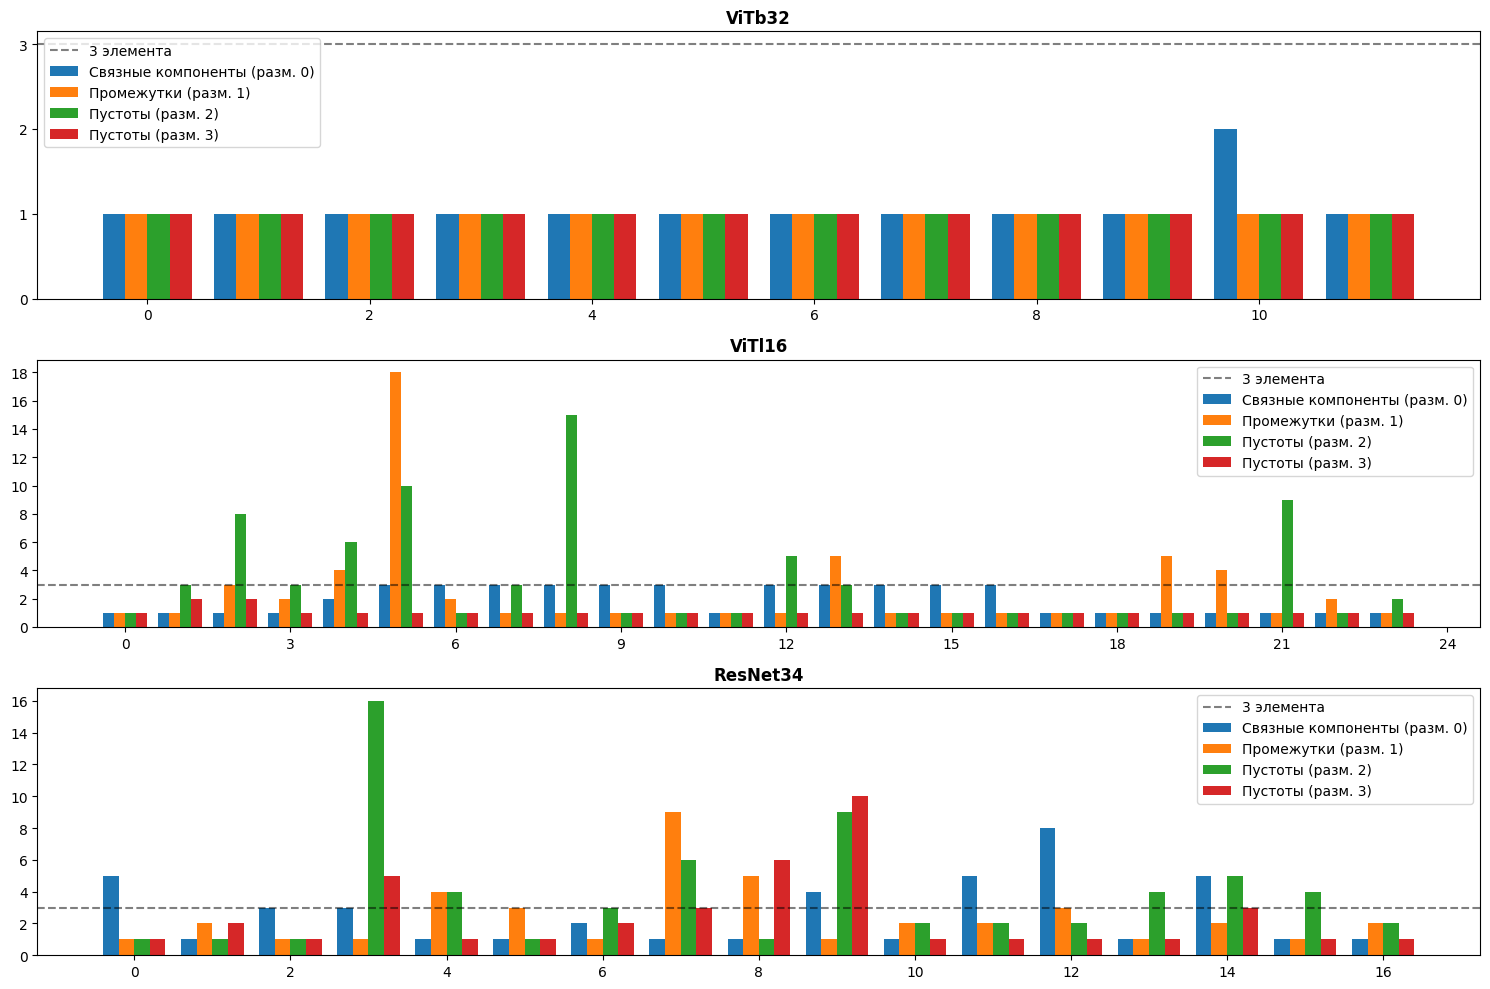

In [6]:
import matplotlib.pyplot as plt

AX_IDX = { 'vit_l_16': 1, 'vit_b_32': 0, 'resnet34': 2 }
fig, axes = plt.subplots(3, 1, figsize = (15, 10))
for model, title in MODELS.items():
    ax = axes.flat[AX_IDX[model]]
    ax.set_title(title, fontweight='bold')
    zigzag.space.plot(plan(model, PLOT_COMPONENT), ax)
    ax.axhline(
        y=3, color='black', linestyle='dashed', alpha=0.5, label='3 элемента'
    )
    ax.legend(loc='best')

fig.tight_layout()
fig.savefig(f"{ROOT}/spaces_plots.png")
fig.savefig(f"{ROOT}/spaces_plots.svg")